# Working with images

From three colabs: loading and examining an image, image handling with Pillow, and a cats vs dogs classifier.

1. an image is a NumPy array: shape, dtype, channels
2. grayscale, resizing, flattening into a feature vector
3. loading a folder of labelled images
4. random forest on raw pixels, with and without augmentation
5. error analysis

## An image as an array

The colabs used a photo of the Golden Gate bridge uploaded to Colab. To keep this runnable without uploads,
it uses one of the sample photos that ship with scikit-learn instead. To use your own, replace the first line
with `image = Image.open('your_photo.jpg')`.

<class 'PIL.Image.Image'> (640, 427) RGB


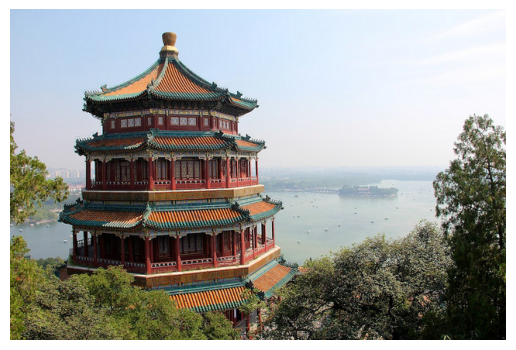

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.datasets import load_sample_image

image = Image.fromarray(load_sample_image('china.jpg'))
print(type(image), image.size, image.mode)

plt.imshow(image)
plt.axis('off')
plt.show()

Pillow reports `size` as (width, height). Converting to a NumPy array gives (height, width, channels), the
usual (rows, columns) order:

In [2]:
image_array = np.array(image)
print("shape:", image_array.shape)
print("dtype:", image_array.dtype)
print("min / max:", image_array.min(), image_array.max())
print("values:", image_array.size)

shape: (427, 640, 3)
dtype: uint8
min / max: 0 255
values: 819840


Every pixel is three numbers, red, green and blue, each an unsigned 8-bit integer from 0 to 255. Even this
small photo is 427 x 640 x 3 = 819,840 numbers. The course photo was 3368 x 5388, over 54 million.

The top-left 5 x 5 pixels (sky, so blue is the largest of the three: 174, 201, 231):

In [3]:
image_array[:5, :5, :]

array([[[174, 201, 231],
        [174, 201, 231],
        [174, 201, 231],
        [174, 201, 231],
        [174, 201, 231]],

       [[172, 199, 229],
        [173, 200, 230],
        [173, 200, 230],
        [174, 201, 231],
        [174, 201, 231]],

       [[174, 201, 231],
        [174, 201, 231],
        [174, 201, 231],
        [174, 201, 231],
        [174, 201, 231]],

       [[175, 202, 232],
        [175, 202, 232],
        [175, 202, 232],
        [175, 202, 232],
        [174, 201, 231]],

       [[174, 201, 230],
        [174, 201, 230],
        [175, 202, 231],
        [175, 202, 231],
        [175, 202, 231]]], dtype=uint8)

### Colour channels

Each channel on its own is a 2D array. Shown in grey, bright means a high value in that channel:

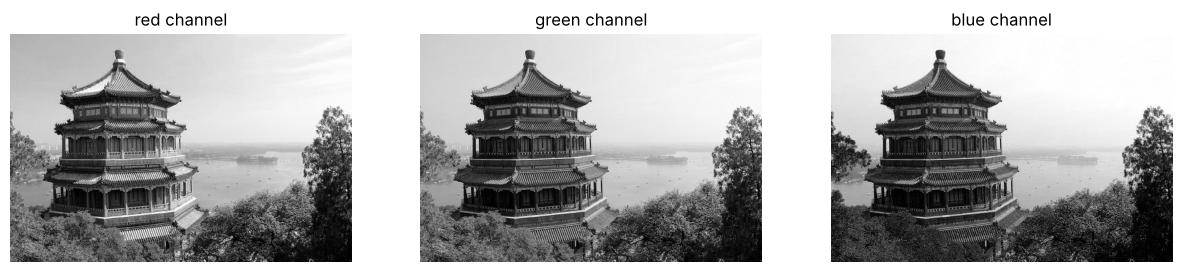

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, (ax, name) in enumerate(zip(axes, ['red', 'green', 'blue'])):
    ax.imshow(image_array[:, :, i], cmap='gray', vmin=0, vmax=255)
    ax.set_title(f'{name} channel')
    ax.axis('off')
plt.show()

The three look alike because most of this scene is fairly neutral in colour. The differences are in the
averages: the sky is brightest in blue (about 212 red, 228 green, 247 blue), while the trees in the bottom
right are darkest in blue (about 30, 32, 21), since foliage reflects green and red more than blue.

### Grayscale, resize, flatten

Most classic ML models want each sample as one flat row of numbers, all the same length. Three steps get
there:

* `convert('L')`: one channel instead of three. Pillow uses $L = 0.299R + 0.587G + 0.114B$ (green counts
  most, matching how bright it looks to us).
* `resize((w, h))`: every image to the same size. Note it ignores the aspect ratio, so images get squashed.
* `flatten()`: the 2D grid into one long vector, row by row.

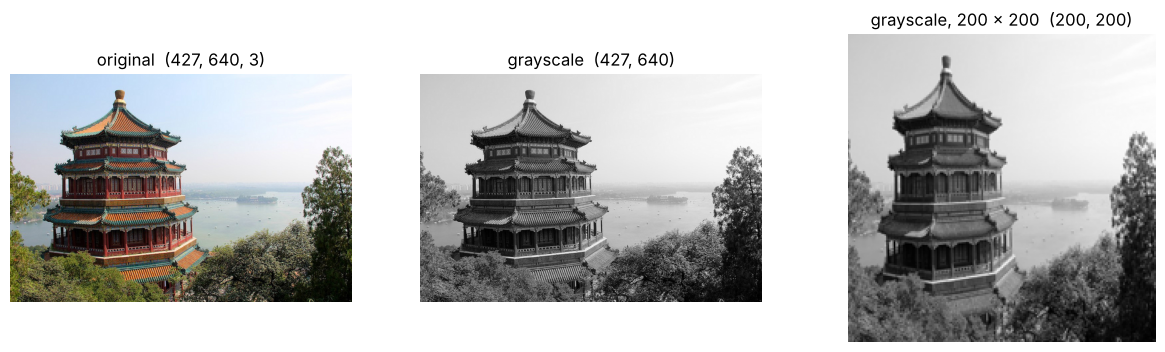

colour 200x200 flattened: (120000,)
gray 200x200 flattened:   (40000,)


In [5]:
gray = image.convert('L')
small = gray.resize((200, 200))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, im, title in zip(axes, [image, gray, small],
                         ['original', 'grayscale', 'grayscale, 200 x 200']):
    ax.imshow(im, cmap='gray' if im.mode == 'L' else None)
    ax.set_title(f"{title}  {np.array(im).shape}")
    ax.axis('off')
plt.show()

print("colour 200x200 flattened:", np.array(image.resize((200, 200))).flatten().shape)
print("gray 200x200 flattened:  ", np.array(small).flatten().shape)

`plt.imshow` on a single-channel image uses the `viridis` colour map unless told otherwise, which is why the
grayscale cats in the course colab came out green and yellow. Pass `cmap='gray'`.

The flattened vector throws away the 2D structure: pixel 200 is directly below pixel 0, but nothing in the
vector says so. That matters later.

## Cats vs dogs

The course used the [cats-and-dogs mini dataset](https://www.kaggle.com/datasets/aleemaparakatta/cats-and-dogs-mini-dataset)
from Kaggle (1,000 images from the Dogs vs Cats competition, half of each). To run this:

1. download the zip from Kaggle (needs a free account)
2. upload it to Colab, then

```
!mkdir -p dataset && unzip -q archive.zip -d dataset
```

The folder should look like `dataset/cats/*.jpg` and `dataset/dogs/*.jpg`. The folder name is the label.

The outputs below are from a run on 500 cats and 500 dogs from the same Dogs vs Cats images, so the numbers
are close to but not exactly the same as the course's.

In [6]:
DATA_DIR = 'dataset'
for class_name in sorted(os.listdir(DATA_DIR)):
    print(class_name, len(os.listdir(os.path.join(DATA_DIR, class_name))))

cats 500
dogs 500


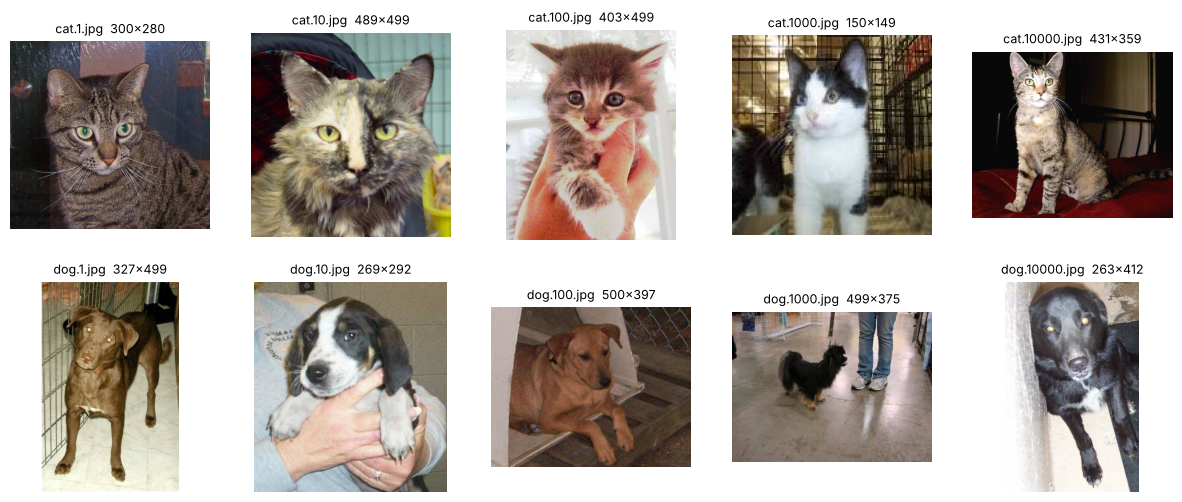

In [7]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for row, class_name in zip(axes, ['cats', 'dogs']):
    files = sorted(os.listdir(os.path.join(DATA_DIR, class_name)))[:5]
    for ax, f in zip(row, files):
        im = Image.open(os.path.join(DATA_DIR, class_name, f))
        ax.imshow(im)
        ax.set_title(f"{f}  {im.size[0]}x{im.size[1]}", fontsize=9)
        ax.axis('off')
plt.show()

Every photo has a different size, the animals are in different poses and positions, and the backgrounds are
cluttered. That's why they need resizing, and also why this is hard for a model that only sees pixel values.

### Loading everything

Same steps as above for every file: grayscale, 200 x 200, flatten, scale to 0-1. Two changes from the
course version:

* `sorted(os.listdir(...))`: `os.listdir` order isn't guaranteed, so without sorting the data (and the
  results) can change from machine to machine
* the try/except now reports and skips unreadable files instead of stopping

In [8]:
IMG_SIZE = (200, 200)

def load_images(data_dir, target_size=IMG_SIZE):
    images, labels = [], []
    for class_name in sorted(os.listdir(data_dir)):
        class_dir = os.path.join(data_dir, class_name)
        for image_name in sorted(os.listdir(class_dir)):
            try:
                im = Image.open(os.path.join(class_dir, image_name)).convert('L').resize(target_size)
            except OSError as e:
                print("skipping", image_name, e)
                continue
            images.append(np.array(im).flatten() / 255.0)
            labels.append(class_name)
    return np.array(images), np.array(labels)

images, labels = load_images(DATA_DIR)
print(images.shape, labels.shape)

(1000, 40000) (1000,)


1,000 samples and 40,000 features: far more features than samples.

### Split and encode labels

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

train_images, test_images, train_labels, test_labels = train_test_split(
    images, labels, test_size=0.2, random_state=42, stratify=labels)

label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(train_labels)
y_test = label_encoder.transform(test_labels)

print("train:", train_images.shape, " test:", test_images.shape)
print(train_labels[:5], "->", y_train[:5], " classes:", label_encoder.classes_)

train: (800, 40000)  test: (200, 40000)
['dogs' 'cats' 'dogs' 'cats' 'dogs'] -> [1 0 1 0 1]  classes: ['cats' 'dogs']


(scikit-learn classifiers accept string labels directly, so the encoder isn't strictly needed. It's kept
because later code works with 0/1. The course colab's classification report printed "cats"/"dogs" while
comparing against encoded labels, so the cells were probably run out of order there.)

### Baseline: random forest on raw pixels

In [10]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(train_images, y_train)
y_pred = rf.predict(test_images)

print(classification_report(y_test, y_pred, target_names=label_encoder.classes_, digits=3))

              precision    recall  f1-score   support

        cats      0.604     0.640     0.621       100
        dogs      0.617     0.580     0.598       100

    accuracy                          0.610       200
   macro avg      0.610     0.610     0.610       200
weighted avg      0.610     0.610     0.610       200



0.61 accuracy, on a perfectly balanced test set where guessing gets 0.50. Better than chance, but not by
much. (The course run got 0.65, with augmentation; that comparison comes below.)

Which pixels does the forest use? The feature importances, put back into a 200 x 200 grid:

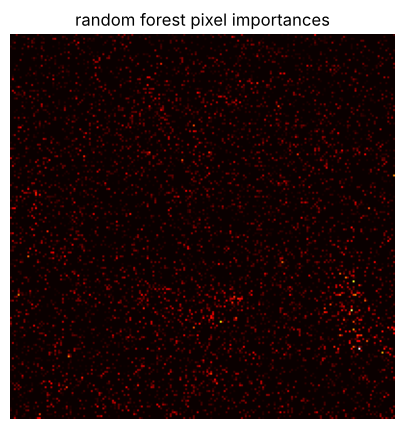

In [11]:
plt.figure(figsize=(5, 5))
plt.imshow(rf.feature_importances_.reshape(IMG_SIZE), cmap='hot')
plt.title('random forest pixel importances')
plt.axis('off')
plt.show()

Speckle with no shape to it: no outline of an ear or a face. Each tree splits on single pixel values like
"pixel (143, 87) brighter than 0.4", and since the animals are in a different place in every photo, no
single pixel means much. Whatever signal there is comes from brightness and texture spread across the image
(dark backgrounds, fur colour), not from what cats and dogs look like.

### Data augmentation

The idea: a cat rotated by 20 degrees is still a cat. Adding rotated copies of the training images gives the
model more (and more varied) examples for free.

Augmentation goes on the **training set only**, after the split. If augmented copies of an image were made
before splitting, a rotated copy could end up in the test set while the original is in training, and the
test score would be too optimistic. The test set stays as the real, untouched photos.

Two fixes to the course function: the random angles come from a seeded generator (the original used
`random.uniform` without a seed, so every run was different), and the image size isn't hard-coded.

In [12]:
def augment_rotate(images, labels, factor=2, max_angle=30, size=IMG_SIZE, seed=42):
    rng = np.random.default_rng(seed)
    out_images, out_labels = [], []
    for image, label in zip(images, labels):
        out_images.append(image)
        out_labels.append(label)
        img = Image.fromarray((image.reshape(size) * 255).astype(np.uint8))
        for _ in range(factor):
            rotated = img.rotate(rng.uniform(-max_angle, max_angle))
            out_images.append(np.array(rotated).flatten() / 255.0)
            out_labels.append(label)
    return np.array(out_images), np.array(out_labels)

x_train_aug, y_train_aug = augment_rotate(train_images, y_train)
print("training data:", x_train_aug.shape, y_train_aug.shape)

training data: (2400, 40000) (2400,)


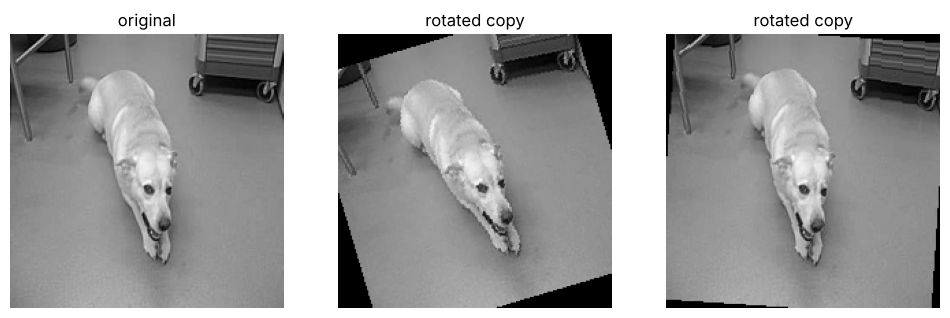

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, im in zip(axes, x_train_aug[:3]):
    ax.imshow(im.reshape(IMG_SIZE), cmap='gray')
    ax.axis('off')
axes[0].set_title('original')
axes[1].set_title('rotated copy')
axes[2].set_title('rotated copy')
plt.show()

Note the black corners: `rotate` keeps the original canvas size and fills the gaps with 0.

In [14]:
rf_aug = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_aug.fit(x_train_aug, y_train_aug)
y_pred_aug = rf_aug.predict(test_images)
print(classification_report(y_test, y_pred_aug, target_names=label_encoder.classes_, digits=3))

              precision    recall  f1-score   support

        cats      0.637     0.650     0.644       100
        dogs      0.643     0.630     0.636       100

    accuracy                          0.640       200
   macro avg      0.640     0.640     0.640       200
weighted avg      0.640     0.640     0.640       200



0.61 to 0.64 on this test split. That looks like augmentation helped, in line with the course result of
0.65. But it's a difference of 6 images out of 200.

A test set of 200 images is small: one image is half a percentage point, and the standard error on an
accuracy around 0.6 is about $\sqrt{0.6 \cdot 0.4 / 200} \approx 0.035$. To compare properly, 5-fold cross
validation on all 1,000 images, augmenting only the training folds each time. A horizontal flip is added as a
third option: it creates no black corners, and a mirrored cat is still a cat.

In [15]:
from sklearn.model_selection import StratifiedKFold

y_all = label_encoder.transform(labels)

def augment_flip(images, labels, size=IMG_SIZE):
    flipped = np.array([np.fliplr(im.reshape(size)).flatten() for im in images])
    return np.vstack([images, flipped]), np.concatenate([labels, labels])

options = {
    'no augmentation': lambda X, y: (X, y),
    'rotation x2': augment_rotate,
    'horizontal flip': augment_flip,
}
cv_scores = {name: [] for name in options}

for fold, (tr, te) in enumerate(StratifiedKFold(5, shuffle=True, random_state=42).split(images, y_all)):
    for name, augment in options.items():
        X_tr, y_tr = augment(images[tr], y_all[tr])
        model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1).fit(X_tr, y_tr)
        cv_scores[name].append(model.score(images[te], y_all[te]))

import pandas as pd
cv_table = pd.DataFrame(cv_scores, index=[f'fold {i + 1}' for i in range(5)])
cv_table.loc['mean'] = cv_table.mean()
cv_table.round(3)

,no augmentation,rotation x2,horizontal flip
fold 1,0.550,0.600,0.630
fold 2,0.670,0.610,0.700
fold 3,0.565,0.550,0.600
fold 4,0.580,0.535,0.550
fold 5,0.550,0.560,0.590
mean,0.583,0.571,0.614


With cross validation the picture changes:

* rotation doesn't help at all (0.571 vs 0.583). The 0.61 to 0.64 above was luck of the split.
* the flip is a bit better (0.614), and better in 4 of the 5 folds, but the folds themselves range from 0.55
  to 0.70, so that's weak evidence.

Why doesn't rotation help? A random forest treats pixel (100, 100) as a fixed feature. A rotated copy moves
every part of the animal to different pixels and adds black corners, so to the forest it's mostly a new,
noisy sample. It has no way to learn "this is the same thing, turned". Flipping keeps the image content and
its statistics (no black corners) and roughly half the photos would be framed that way anyway.

### Error analysis

The course loop had a bug: `errors` already holds the positions of the wrong predictions, and the loop then
indexed with `errors[error_index]` again. Since the values in `errors` are themselves error positions, it
happened to still show wrong predictions, just not the first ten, and it would crash as soon as a position
was larger than the number of errors. Indexing directly with each position fixes it. A grid is easier to scan than ten separate plots:

78 of 200 test images wrong


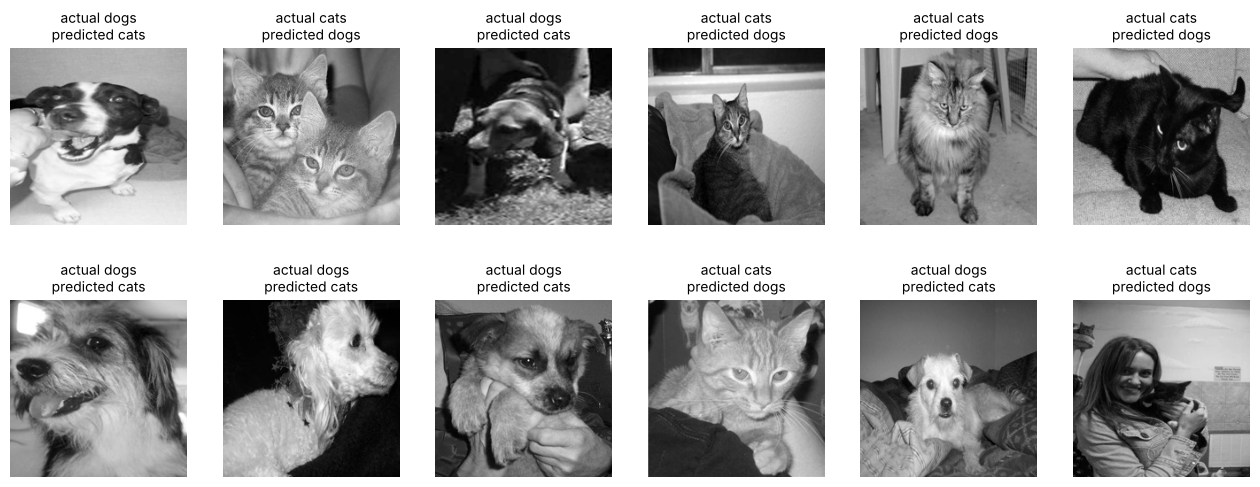

In [16]:
errors = np.where(y_pred != y_test)[0]
print(f"{len(errors)} of {len(y_test)} test images wrong")

fig, axes = plt.subplots(2, 6, figsize=(16, 6))
for ax, idx in zip(axes.ravel(), errors[:12]):
    ax.imshow(test_images[idx].reshape(IMG_SIZE), cmap='gray')
    actual = label_encoder.classes_[y_test[idx]]
    predicted = label_encoder.classes_[y_pred[idx]]
    ax.set_title(f"actual {actual}\npredicted {predicted}", fontsize=10)
    ax.axis('off')
plt.show()

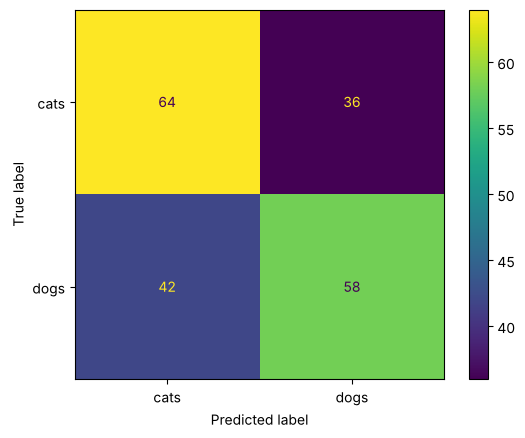

In [17]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=label_encoder.classes_)
plt.show()

The mistakes are not hard cases for a person: clear faces of dogs and cats, mostly centred. Cats get called
dogs 36 times and dogs get called cats 42 times, so no strong bias either way. The model just isn't seeing
"cat" or "dog" at all, which matches the importance map.

## Summary

* an image is an array of shape (height, width, channels) with `uint8` values 0-255
* for classic ML: grayscale, resize to a fixed size, flatten, scale to 0-1
* `sorted(os.listdir(...))` for reproducible loading; use `cmap='gray'` for single-channel images
* augment the training data only, after the split, and with a seed
* a random forest on raw pixels gets only a bit better than chance on cats vs dogs (about 0.6), and
  augmentation doesn't rescue it. Check a small improvement with cross validation before believing it. The model has no idea which pixels are next to each other. Models that do (convolutional
  neural networks) are the standard tool for images, and that's where augmentation pays off